# Predicting Student Mental Health Score from Social Media Usage
- **Problem:** We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

- **Dataset:** Student_Social_Media_And_Mental_Health_Impact.csv

- **Model:** Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, XGBoost Regressor

### Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
- We load the CSV and take a first look at its shape and the first few rows. And create shallow copy of the data. **This is always the first step**

In [2]:
data = pd.read_csv(r"D:\ML_Project\Student Mental Health_Score_Prediction\Data\Student Social Media And Mental Health Impact.csv")

In [3]:
data.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
data.shape

(5000, 13)

### Create a shallow copy of data

In [5]:
df = data.copy()

### Basic data understanding
- Check the no. of rows and columns
- Check column names
- Check data types
- Get basic information
- Check missing values
- Check duplicate records
- Statistical summary

In [6]:
# Look at first 5 rows.
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [112]:
df['Avg_Daily_Usage_Hours'].value_counts().index.to_list()

[4.7,
 3.8,
 5.6,
 4.6,
 4.5,
 3.7,
 5.7,
 5.8,
 5.9,
 4.4,
 6.2,
 4.8,
 3.9,
 4.3,
 6.0,
 5.2,
 5.5,
 6.4,
 3.6,
 4.0,
 4.2,
 5.3,
 4.1,
 6.1,
 5.4,
 7.0,
 3.4,
 4.9,
 6.3,
 3.5,
 6.9,
 7.2,
 6.5,
 5.1,
 6.8,
 3.2,
 3.3,
 5.0,
 7.3,
 6.7,
 6.6,
 7.1,
 3.0,
 3.1,
 2.8,
 2.9,
 7.5,
 7.4,
 2.5,
 7.6,
 2.6,
 7.7,
 8.0,
 8.2,
 8.1,
 7.9,
 2.3,
 2.7,
 2.0,
 7.8,
 2.2,
 1.9,
 2.4,
 2.1,
 8.3,
 8.4,
 1.8,
 1.7,
 1.6,
 1.5,
 8.5,
 8.6,
 1.4,
 8.7,
 8.8,
 1.3,
 1.2,
 1.0,
 1.1]

In [7]:
# check how many no. of rows and column
df.shape

(5000, 13)

In [8]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

In [9]:
df.dtypes

Age                          int64
Gender                      object
Country                     object
Academic_Level              object
Most_Used_Platform          object
Purpose_Of_Use              object
Avg_Daily_Usage_Hours      float64
Daily_Unlocks                int64
Study_Hours                float64
Physical_Activity_Hours    float64
Sleep_Hours_Per_Night      float64
Stress_Level                object
Mental_Health_Score        float64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [11]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2)

**two duplicates rows count**

In [13]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


**Note:** Most columns look reasonable — but look closely at **Physical_Activity_Hours:** the minimum value is -0.4. Negative hours aren't physically possible, so this is a data-entry glitch, not a real value. We'll fix this properly in the Data Cleaning step below instead of ignoring it.

### Exploratory Data Analysis (EDA)

#### Target Distribution(Mental_Health_Score) 

- Before predicting anything, we need to understand the shape(Distribution) of what we're predicting.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

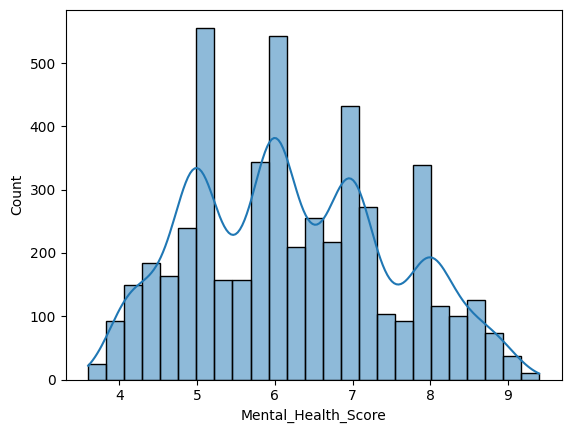

In [14]:
sns.histplot(df['Mental_Health_Score'], kde = True)

**Note:** Here shows multiple bell-shaped curves or peaks, we cannot directly conclude that the data is normally distributed.
We should also check skewness before deciding whether the data is normally distributed.

### Correlation heatmap
- only work with numerical column

<Axes: >

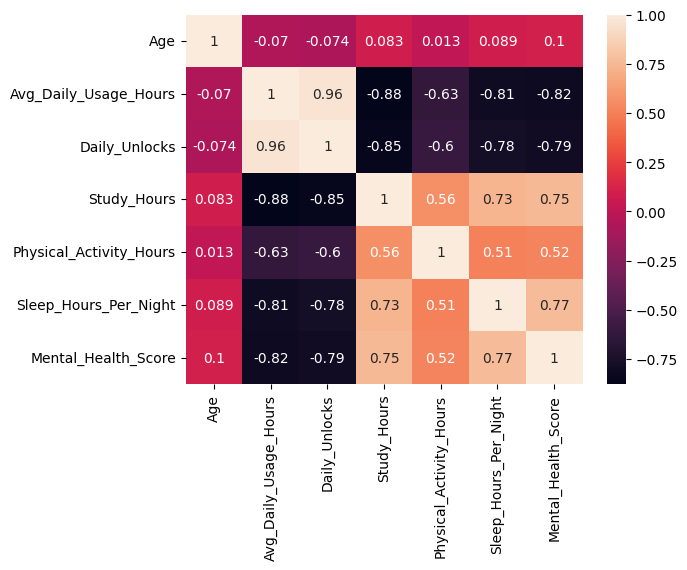

In [15]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

### Stress_Level vs Mental_Health_Score
Does higher stress genuinely come with a lower score?

In [16]:
df["Stress_Level"].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

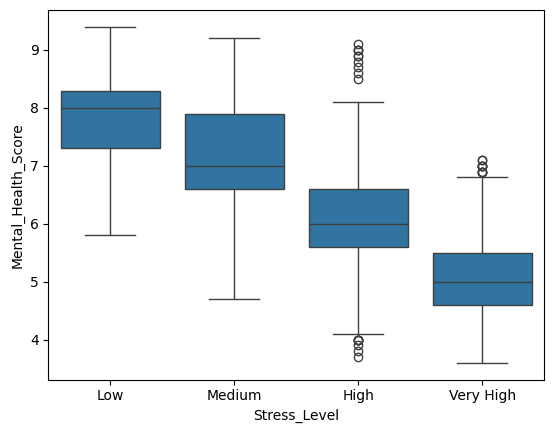

In [17]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(data = df, x = 'Stress_Level', y = 'Mental_Health_Score', order = order)

In [18]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

### Avg_Daily_Usage_Hours vs 'Mental_Health_Score'


<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

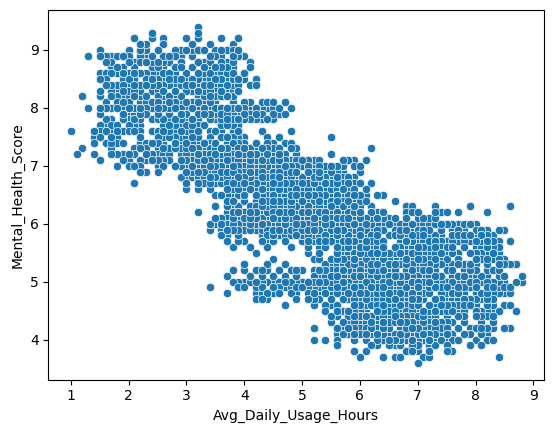

In [19]:
sns.scatterplot(data = df, x = 'Avg_Daily_Usage_Hours', y = 'Mental_Health_Score')

*we observe that, -ve correlation between them*

<Axes: xlabel='Age', ylabel='Mental_Health_Score'>

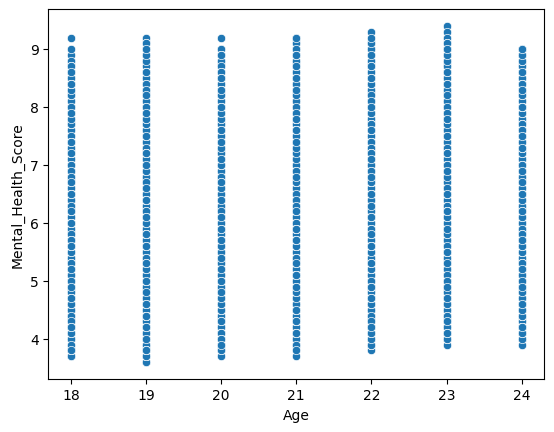

In [20]:
sns.scatterplot(data = df, x = 'Age', y = 'Mental_Health_Score')

### Sleep_Hours_Per_Night vs Mental_Health_Score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

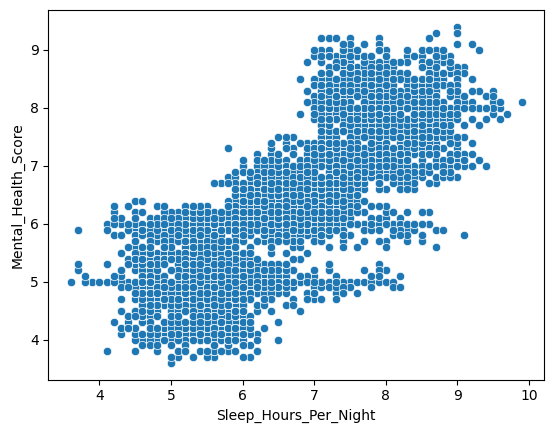

In [21]:
sns.scatterplot(data = df, x = 'Sleep_Hours_Per_Night', y = 'Mental_Health_Score')

### Most used platform

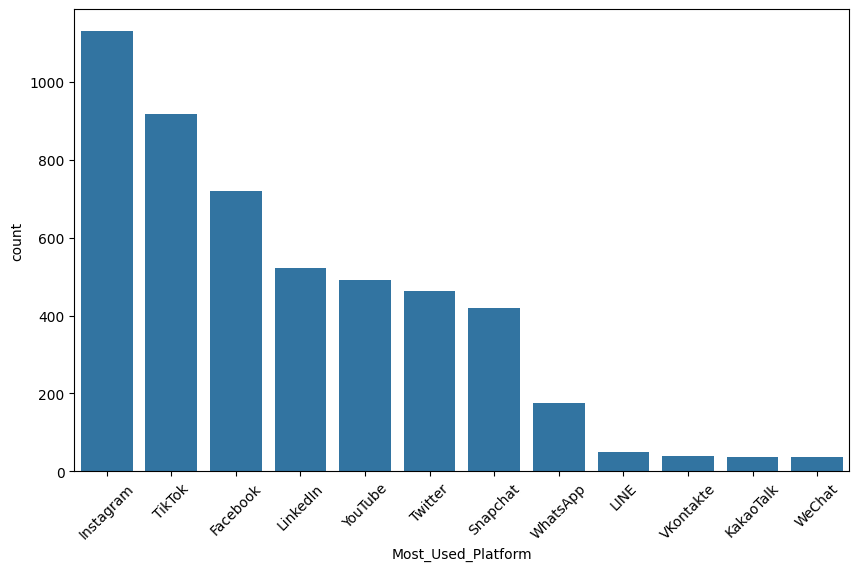

In [22]:
plt.figure(figsize = (10,6))
sns.countplot(data = df, x = 'Most_Used_Platform', order = df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=45)
plt.show()

### Count gender

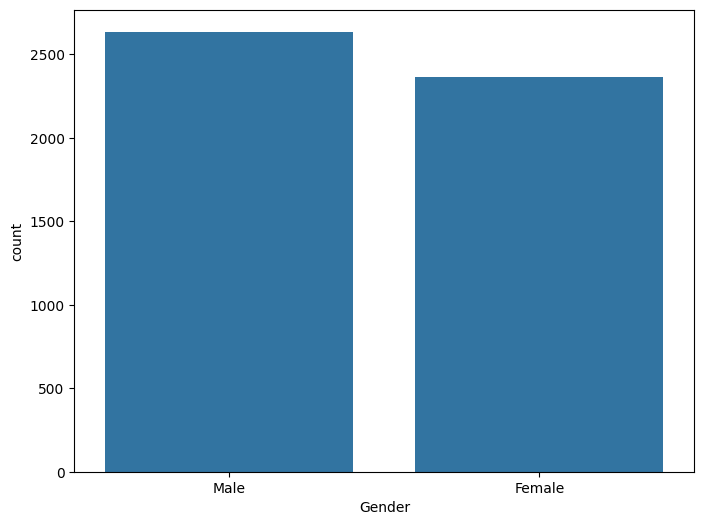

In [23]:
plt.figure(figsize = (8,6))
sns.countplot(data = df, x = 'Gender')
plt.show()

### Check Outliers

In [24]:
num_features = df.select_dtypes(include = 'number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())



Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


### Data Cleaning

Two real issues to fix here — everything else in this dataset is already clean, so we don't manufacture cleaning steps that aren't needed.

In [25]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [26]:
# drop duplicate
df = df.drop_duplicates()

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
# Converting negative or unrealitstic value to realistic value.
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

📌 Why clip(lower=0) and not dropping the row: the rest of that student's data (age, study hours, stress level, etc.)
is still valid and useful — throwing away the whole row over one bad value wastes good data. 
Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.
  clip(lower=0)  used when value less than 0 other wise use clip(upper= ..)

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, 
and we already confirmed none of them are empty or constant.

### Skewness

**What skewness is:** a measure of how lopsided a numeric column's distribution is. 
A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, 
with a long tail.

**Why it matters:** models like Linear Regression assume features are roughly well-behaved. 
A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction.
Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [29]:
num_cols = df.select_dtypes(include = 'number')
skew_data = num_cols.skew()
print(skew_data)

# near to 0 -> Centralized (0.01, 0.002)
# negative -> Left Skewed (-1.56)
# poistive (greater than 0) -> Right Skewed (1.256)

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64


<Axes: xlabel='Study_Hours', ylabel='Count'>

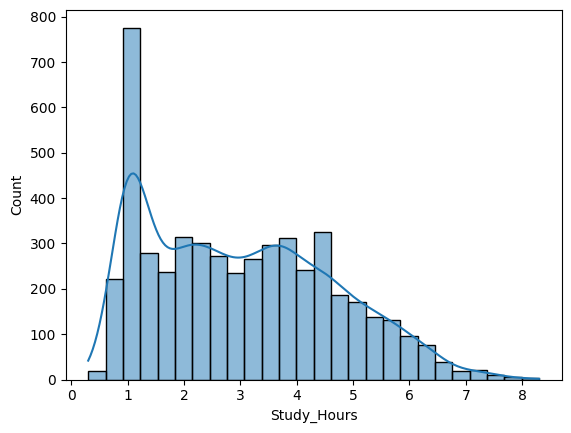

In [30]:
sns.histplot(df['Study_Hours'], kde = True)

In [31]:
df['Study_Hours'].value_counts().head(10)

Study_Hours
1.0    503
1.2    140
1.1    133
1.3    118
2.0    113
2.4    112
3.7    111
3.5    106
3.9    102
2.1    102
Name: count, dtype: int64

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Count'>

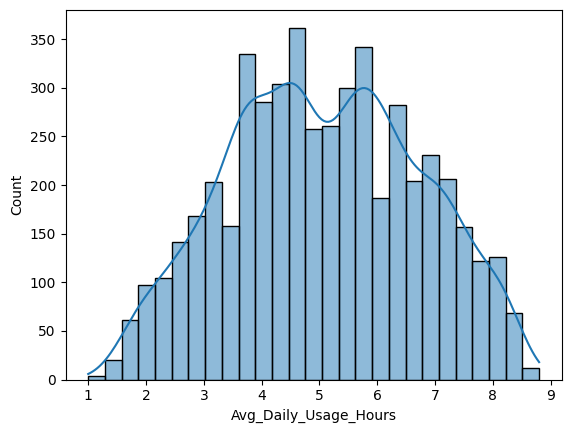

In [32]:
sns.histplot(df['Avg_Daily_Usage_Hours'], kde = True)

### Feature Engineering

In [33]:
df['Country'].nunique()

111

**One meaningful engineered feature here: grouping Country.**
- Country has **111 unique values** in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
- **The fix:** keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [34]:
top_countries = df['Country'].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [35]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [36]:
import warnings
warnings.filterwarnings("ignore")

In [37]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [38]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [39]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

### Encoding Strategy

Before we jump into code, let's decide how each categorical column should be encoded — this decision matters more than the code itself.

- Stress_Level → Ordinal Encoding. Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
- Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Country_Grouped → One-Hot Encoding. These categories have no natural order — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single ColumnTransformer in the next step, 
rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

### Train-Test Split

**Why we split:** we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

**Common ratios:** 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

**We split before fitting any preprocessing —** this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [40]:
from sklearn.model_selection import train_test_split

In [82]:
skewed_col         = ['Study_Hours']
numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_cat_col    = ['Stress_Level']
normal_cat_col     = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]


feature_col = skwewd_col + numeric_cols + ordinal_cat_col + normal_cat_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

### Preprocessing

Our columns need different treatment:

- Study_Hours (the skewed one) → impute → log1p transform → scale
- The other numeric columns → impute → scale (no skew to fix)
- Stress_Level → impute → OrdinalEncoder with an explicit order
- The nominal columns → impute → OneHotEncoder

when our dataset has different types of columns that need different preprocessing. then we use **ColumnTransformer**

- We include a **SimpleImputer** in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

- **ColumnTransformer** glues all of this into one object that applies the right transformation to the right column type in a single .fit() / .transform() call — no manual column-by-column juggling.

**FunctionTransformer.log1p()** used reduce skewness

In [43]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country'],
      dtype='object')

In [44]:
df['Stress_Level'].value_counts()

Stress_Level
Very High    1621
High         1439
Medium       1295
Low           643
Name: count, dtype: int64

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

### Data preprocessing 

In [84]:
#skewed_feature
skew_pipeline = Pipeline(steps = [
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

#numeric_column
num_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])

#ordinal_cat feature
ord_pipeline = Pipeline(steps = [
    ('ordinal_encode', OrdinalEncoder(categories = [['Low', 'Medium', 'High', 'Very High']]))
    
])

#normal_cat_feature

cat_pipeline = Pipeline(steps = [
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'))
])

# combine pipeline (konsi_pipeline, konsa_feature)

preprocessor = ColumnTransformer(transformers = [
    ("Skewed_Pipeline", skew_pipeline, skewed_col),
    ("Numeric",num_pipeline, numeric_cols ),
    ('Ordinal_cat', ord_pipeline, ordinal_cat_col),
    ('Normal_cat', cat_pipeline, normal_cat_col)
    
])

### Build a Pipeline
- **Why Pipeline matters:** a Pipeline chains preprocessing and the model into a single object. Calling .fit() once does both steps in the correct order, and calling .predict() on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

- **Why companies prefer this:** when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know anything about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls .predict() on raw input. That's a huge reduction in what can go wrong in production.

- We'll build two pipelines below — one per model — so we can fairly compare them.

### Model Building

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn import metrics

In [85]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        objective='reg:squarederror'
    )
}

In [52]:
from sklearn.model_selection import GridSearchCV

In [86]:
param_grid = {
    "Linear Regression": {},

    'Decision Tree': {
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10],
        "model__min_samples_split": [5, 10],
        "model__min_samples_leaf": [2, 5]
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 100],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5]
    },
    'XGBoost': {
        'model__n_estimators': [50, 100],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5]
    }
}

### Model Training & Hyperparameter tuning

In [87]:
results = []
best_models = {}

for model_name, model in models.items():

    print(f"Model Training: {model_name}")

    # Complete pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Hyperparameter tuning
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid[model_name],
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    # Train
    grid.fit(X_train, y_train)

    # Store best pipeline
    best_models[model_name] = grid.best_estimator_

    # Prediction
    y_pred = grid.best_estimator_.predict(X_test)

    # Store results
    results.append({
        "Model": model_name,
        "MAE": round(metrics.mean_absolute_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)), 4),
        "R² Score": round(metrics.r2_score(y_test, y_pred), 4),
        "Best Params": grid.best_params_
    })

Model Training: Linear Regression
Model Training: Decision Tree
Model Training: Random Forest
Model Training: Gradient Boosting
Model Training: XGBoost


In [59]:
import joblib

In [88]:
# Model Comparison
result_df = pd.DataFrame(results)

# Sort by R² Score (best model first)
result_df = result_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

print("Model Comparison:\n")
print(result_df)

# Select the best model
best_model_name = result_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Parameters:", result_df.iloc[0]["Best Params"])

# Save the complete preprocessing + model pipeline
TRAINED_MODEL_PATH = r"D:\ML_Project\Student Mental Health_Score_Prediction\best_model.pkl"

joblib.dump(best_model, TRAINED_MODEL_PATH)

print(f"\nBest model saved successfully to: {TRAINED_MODEL_PATH}")

Model Comparison:

               Model     MAE    RMSE  R² Score  \
0      Random Forest  0.3994  0.5211    0.8479   
1            XGBoost  0.4047  0.5320    0.8415   
2  Gradient Boosting  0.4067  0.5319    0.8415   
3      Decision Tree  0.4526  0.6075    0.7933   
4  Linear Regression  0.5339  0.6776    0.7428   

                                         Best Params  
0  {'model__max_depth': 10, 'model__min_samples_l...  
1  {'model__learning_rate': 0.1, 'model__max_dept...  
2  {'model__learning_rate': 0.1, 'model__max_dept...  
3  {'model__max_depth': 10, 'model__min_samples_s...  
4                                                 {}  

Best Model: Random Forest
Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best model saved successfully to: D:\ML_Project\Student Mental Health_Score_Prediction\best_model.pkl


### Check overfitting

In [89]:
best_rf = best_models["Random Forest"]

# Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# R² Score
train_r2 = metrics.r2_score(y_train, y_train_pred)
test_r2 = metrics.r2_score(y_test, y_test_pred)

# Differences
r2_diff = train_r2 - test_r2

# Print results
print("Training R² :", round(train_r2, 4))
print("Testing R²  :", round(test_r2, 4))
print("R² Difference :", round(r2_diff, 4))

Training R² : 0.8996
Testing R²  : 0.8479
R² Difference : 0.0518


The Random Forest model shows **some overfitting** because the training performance is better than the testing performance. However, the **R² difference of 0.0518 is relatively small**, and the **testing R² of 0.8479 is strong**.

Therefore, the model has **good generalization performance** and is suitable for predicting the **Student Mental Health Score**.